# EDA - Gruppo 3: Giorni di consegna

**Domanda di business:** la promessa di consegna e' tarata bene?

- **Target (regressione):** giorni tra acquisto e consegna effettiva.
- **Baseline da battere:** la stima ufficiale dell'e-commerce (giorni tra acquisto e data stimata).
- **Vincolo:** solo feature note al momento del checkout (niente info sulla consegna effettiva tra le feature).

> Questo e' uno **scheletro**: le sezioni con `# TODO` sono la parte che scrivete voi durante la giornata (EDA, distribuzioni, errore della baseline).

## Setup
Aggiungiamo la radice del progetto al path per importare `src/`, poi carichiamo le funzioni condivise.

In [1]:
import sys
from pathlib import Path

# La radice del progetto e' la cartella che contiene 'src'.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader
from src.sql import query, list_tables

pd.set_option('display.max_columns', 50)

## 1. Profilazione delle nove tabelle
Prima di costruire qualsiasi cosa: quante righe, che colonne, quanti nulli, quali chiavi. E' qui che, come dice la slide 6, nasce il 90% degli errori.

In [2]:
# Demo: carica tutte le tabelle grezze e mostra le dimensioni.
raw = data_loader.load_all_raw()
for name, df in raw.items():
    print(f'{name:22s} {df.shape[0]:>9,} righe x {df.shape[1]:>2} colonne')

orders                    99,441 righe x  8 colonne
order_items              112,650 righe x  7 colonne
order_payments           103,886 righe x  5 colonne
order_reviews             99,224 righe x  7 colonne
products                  32,951 righe x  9 colonne
customers                 99,441 righe x  5 colonne
sellers                    3,095 righe x  4 colonne
geolocation            1,000,163 righe x  5 colonne
category_translation          71 righe x  2 colonne


In [3]:
# Colonne (e tipo) di ogni tabella.
for name, df in raw.items():
    print(f'=== {name}  ({df.shape[0]:,} righe) ===')
    for col, dt in df.dtypes.items():
        print(f'  {col:32s} {dt}')
    print()

=== orders  (99,441 righe) ===
  order_id                         str
  customer_id                      str
  order_status                     str
  order_purchase_timestamp         datetime64[us]
  order_approved_at                datetime64[us]
  order_delivered_carrier_date     datetime64[us]
  order_delivered_customer_date    datetime64[us]
  order_estimated_delivery_date    datetime64[us]

=== order_items  (112,650 righe) ===
  order_id                         str
  order_item_id                    int64
  product_id                       str
  seller_id                        str
  shipping_limit_date              datetime64[us]
  price                            float64
  freight_value                    float64

=== order_payments  (103,886 righe) ===
  order_id                         str
  payment_sequential               int64
  payment_type                     str
  payment_installments             int64
  payment_value                    float64

=== order_reviews  (99,22

In [4]:
# Demo: anteprima di una tabella.
raw['orders'].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [5]:
# TODO: per ogni tabella, profilare nulli, duplicati e chiavi.
#   - df.isna().mean()          -> % di nulli per colonna
#   - df[key].duplicated().sum() -> chiave davvero univoca?
#   - controllare i join 1:N (order_items, order_payments, order_reviews)


## 2. Esplorazione con SQL
Le stesse tabelle sono interrogabili in SQL (SQLite in memoria). Comodo per conteggi, group by e controlli rapidi.

In [6]:
# Tabelle disponibili nel database (le 9 grezze + order_table del Gruppo 3).
list_tables()

,name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,order_table
7,orders
8,products
9,sellers


In [7]:
# Demo: distribuzione degli stati ordine.
query('''
    SELECT order_status, COUNT(*) AS n
    FROM orders
    GROUP BY order_status
    ORDER BY n DESC
''')

,order_status,n
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [8]:
# TODO: esplorazioni SQL vostre. Esempi da cui partire:
#   - ordini per stato/regione cliente
#   - quota di ordini multi-venditore (n_sellers > 1) in order_table
#   - volumi per periodo (mese di acquisto)


## 3. Costruzione della tabella ordine
`build_order_table()` porta tutto a grana-ordine (una riga = un ordine), filtra ai soli ordini consegnati e calcola **target** e **baseline**. Le relazioni 1:N sono gia' aggregate prima del join.

In [9]:
order_table = data_loader.build_order_table()
print(f'{order_table.shape[0]:,} ordini x {order_table.shape[1]} colonne')
order_table[['order_id', 'delivery_days', 'estimated_days',
             'n_items', 'n_sellers', 'total_price', 'customer_state']].head()

96,470 ordini x 23 colonne


,order_id,delivery_days,estimated_days,n_items,n_sellers,total_price,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,1,1,29.99,SP
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,1,1,118.70,BA
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,1,1,159.90,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,1,1,45.00,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,1,1,19.90,SP


## 4. Target e baseline
- `delivery_days` = giorni reali di consegna (quello che vogliamo prevedere).
- `estimated_days` = promessa dell'e-commerce (la baseline da battere).

**Questa e' la parte valutata: fatela voi.**

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64


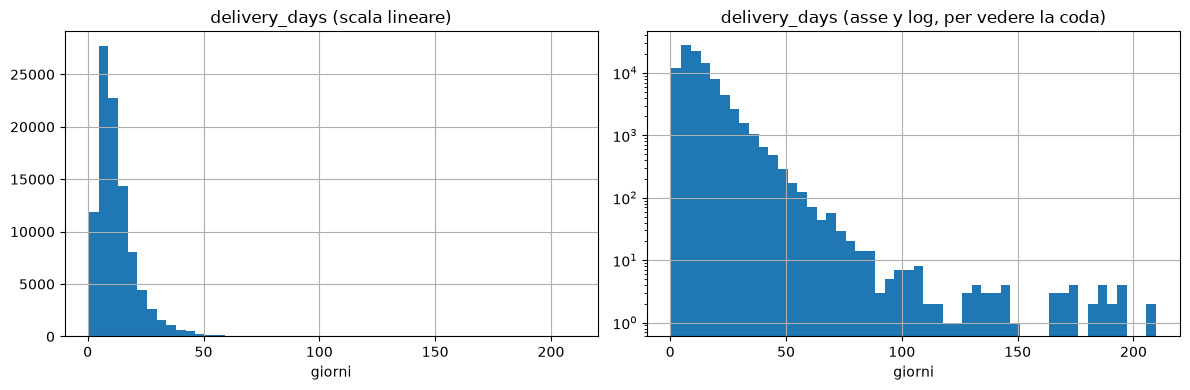

In [10]:
# Distribuzione del target: giorni di consegna effettivi.
print(order_table['delivery_days'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order_table['delivery_days'].hist(bins=50, ax=axes[0])
axes[0].set_title('delivery_days (scala lineare)')
axes[0].set_xlabel('giorni')

order_table['delivery_days'].hist(bins=50, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('delivery_days (asse y log, per vedere la coda)')
axes[1].set_xlabel('giorni')

plt.tight_layout()
plt.show()

count    96470.000000
mean        11.178126
std         10.184354
min       -188.975081
25%          6.389815
50%         11.948102
75%         16.244065
max        146.016123
Name: baseline_error, dtype: float64

MAE baseline: 12.73 giorni
Quota di ordini in ritardo rispetto alla stima: 8.1%


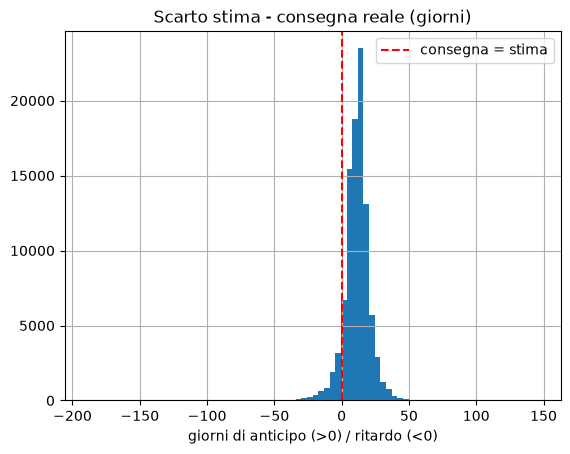


Col tasso di ritardo attuale (8.1%) non si puo' accorciare: bisognerebbe allungare la promessa di 3.8 giorni per scendere sotto il 5% di ritardi.


In [11]:
# Errore della baseline (stima ufficiale vs consegna reale).
# scarto > 0  -> consegnato in anticipo rispetto alla stima
# scarto < 0  -> consegnato in ritardo rispetto alla stima
order_table['baseline_error'] = order_table['estimated_days'] - order_table['delivery_days']

mae_baseline = (order_table['estimated_days'] - order_table['delivery_days']).abs().mean()
late_share = (order_table['baseline_error'] < 0).mean()

print(order_table['baseline_error'].describe())
print(f"\nMAE baseline: {mae_baseline:.2f} giorni")
print(f"Quota di ordini in ritardo rispetto alla stima: {late_share:.1%}")

order_table['baseline_error'].hist(bins=80)
plt.axvline(0, color='red', linestyle='--', label='consegna = stima')
plt.title('Scarto stima - consegna reale (giorni)')
plt.xlabel('giorni di anticipo (>0) / ritardo (<0)')
plt.legend()
plt.show()

# Quanto si potrebbe accorciare la promessa restando sotto il 5% di ritardi?
# Se accorciamo la stima di `x` giorni, un ordine finisce in ritardo quando
# baseline_error < x, quindi cerchiamo l'x per cui P(baseline_error < x) = 5%.
margin_5pct = order_table['baseline_error'].quantile(0.05)
if margin_5pct >= 0:
    print(f"\nSi puo' accorciare la promessa di {margin_5pct:.1f} giorni "
          f"restando sotto il 5% di ritardi.")
else:
    print(f"\nCol tasso di ritardo attuale ({late_share:.1%}) non si puo' accorciare: "
          f"bisognerebbe allungare la promessa di {-margin_5pct:.1f} giorni "
          f"per scendere sotto il 5% di ritardi.")

## 5. Prime distribuzioni e feature
Relazioni tra il target e i possibili driver: distanza, peso/volume, tempo di approvazione del pagamento, categoria, carico del venditore.

**Analisi completa svolta in [`02_analisi_feature_gruppo3.ipynb`](02_analisi_feature_gruppo3.ipynb)** (copertura, Spearman, controlli di qualita' e causalita', analisi a fasce). Qui solo il riepilogo.

**Sintesi** (dettagli e grafici in `02_analisi_feature_gruppo3.ipynb`):

- **Distanza venditore-cliente**: driver piu' forte (Spearman ~0.54). Media e max quasi identici; qualita' ok (coordinate anomale >4300 km sono 4 casi su ~96k).
- **Categoria prodotto**: forte spread tra categorie (consegna media ~10 -> ~21 gg).
- **Tempo di approvazione pagamento**: Spearman debole (~0.09) ma a fasce l'effetto e' netto (~12 gg se approvato <1h vs ~15 gg se >3 giorni, effetto boleto). Nota vicino al checkout -> usabile senza leakage.
- **Peso e volume**: effetto debole ma monotono a quintili (~+2 gg dal piu' leggero al piu' pesante). Segnale secondario.
- **Carico venditore** (finestra strettamente causale, 30gg): relazione non monotona, quasi piatta; pesa solo la coda dei venditori molto carichi (>30).

**Per il modello:** distanza e categoria portano il grosso del segnale; le altre tre sono deboli in forma lineare ma catturabili da un modello ad alberi grazie agli effetti a soglia osservati nell'analisi a fasce.

## 6. Salvataggio
Quando la tabella e' pronta, salvatela in `data/processed/` per riusarla nel training e nella dashboard senza ricostruirla.

In [12]:
# Scommentare quando la tabella e' pronta:
# data_loader.build_order_table(save=True)  # -> data/processed/order_table.parquet

## 7. Training con XGBoost (feature piu' importanti)
Selezioniamo le feature con **permutation importance** piu' alta trovata in [`02_analisi_feature_gruppo3.ipynb`](02_analisi_feature_gruppo3.ipynb) (soglia >= 0.005, sotto quella soglia il segnale era rumore):

| feature | permutation importance |
|---|---|
| `distance_km_mean` | 0.273 |
| `total_freight` | 0.026 |
| `distance_km_max` | 0.025 |
| `customer_state` | 0.021 |
| `approval_hours` | 0.020 |
| `total_weight_g` | 0.013 |
| `main_category` | 0.005 |

**Loss asimmetrica:** una previsione **anticipata rispetto alla consegna reale** (il modello dice "arriva prima" e invece arriva dopo) e' peggio di una previsione prudente/posticipata: e' l'equivalente di rompere una promessa al cliente. Penalizziamo quindi gli errori di sotto-stima (`pred < reale`) piu' di quelli di sovra-stima con un **obiettivo XGBoost custom** (errore quadratico pesato in modo asimmetrico).

**Metrica:** giorni di differenza (MAE) rispetto alla consegna effettiva, calcolata sia per la baseline (`estimated_days`) sia per il modello, sullo stesso split temporale usato per la Random Forest in `02_analisi_feature_gruppo3.ipynb`.

In [13]:
from src import features

top_features = ['distance_km_mean', 'total_freight', 'distance_km_max',
                 'customer_state', 'approval_hours', 'total_weight_g', 'main_category']
cat_features = ['customer_state', 'main_category']

ft = features.build_feature_table()
model_df = ft[['order_id', 'purchase_date', 'delivery_days', 'estimated_days'] + top_features].copy()
for c in cat_features:
    model_df[c] = model_df[c].astype('category')

# Stesso split temporale usato per la Random Forest (80% piu' vecchio -> train).
model_df = model_df.sort_values('purchase_date').reset_index(drop=True)
split = int(len(model_df) * 0.8)
train, test = model_df.iloc[:split], model_df.iloc[split:]

X_train, y_train = train[top_features], train['delivery_days']
X_test, y_test = test[top_features], test['delivery_days']
print(f'train: {len(train):,} righe | test: {len(test):,} righe')

train: 77,176 righe | test: 19,294 righe


In [14]:
import numpy as np
from xgboost import XGBRegressor

UNDER_PENALTY = 3.0  # una sotto-stima (consegna prevista troppo presto) pesa 3x una sovra-stima

def asymmetric_mse(y_true, y_pred):
    residual = y_pred - y_true  # < 0 -> il modello ha previsto una consegna troppo anticipata
    weight = np.where(residual < 0, UNDER_PENALTY, 1.0)
    grad = 2 * weight * residual
    hess = 2 * weight
    return grad, hess

xgb_params = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
                   enable_categorical=True, tree_method='hist', random_state=42)

xgb_asym = XGBRegressor(objective=asymmetric_mse, **xgb_params)
xgb_asym.fit(X_train, y_train)

# Controllo: stesso modello con obiettivo simmetrico, per misurare l'effetto della penalita'.
xgb_sym = XGBRegressor(objective='reg:squarederror', **xgb_params)
xgb_sym.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
def summarize(name, pred, y_true):
    err = np.asarray(pred) - np.asarray(y_true)
    mae = np.abs(err).mean()
    early_share = (err < 0).mean()
    print(f'{name:35s} MAE: {mae:5.2f} gg   quota previsioni anticipate: {early_share:5.1%}')

summarize('Baseline (estimated_days)', test['estimated_days'], y_test)
summarize('XGBoost simmetrico', xgb_sym.predict(X_test), y_test)
summarize('XGBoost asimmetrico (penalita anticipo)', xgb_asym.predict(X_test), y_test)

Baseline (estimated_days)           MAE: 13.13 gg   quota previsioni anticipate:  5.3%
XGBoost simmetrico                  MAE:  5.49 gg   quota previsioni anticipate: 14.6%
XGBoost asimmetrico (penalita anticipo) MAE:  8.10 gg   quota previsioni anticipate:  7.5%


**Risultato:**

| modello | MAE (gg) | quota previsioni anticipate |
|---|---|---|
| Baseline (`estimated_days`) | 13.13 | 5.3% |
| XGBoost simmetrico | 5.49 | 14.6% |
| XGBoost asimmetrico (penalita' anticipo) | 8.10 | 7.5% |

Entrambi i modelli battono nettamente la baseline in MAE, ma il simmetrico lo fa "barando" sul rischio che qui conta di piu': **anticipa la consegna quasi 3 volte piu' spesso della baseline** (14.6% vs 5.3%), cioe' promette date che poi non rispetta piu' spesso dell'attuale sistema. Penalizzando la sotto-stima 3x, il modello asimmetrico rinuncia a un po' di MAE (8.10 vs 5.49 gg) per riportare la quota di previsioni anticipate vicino al livello della baseline (7.5% vs 5.3%), restando comunque **molto piu' preciso della baseline attuale** (8.10 vs 13.13 giorni).

**Per il modello:** `UNDER_PENALTY` e' un iperparametro di business, non statistico — va scelto insieme a chi possiede la promessa di consegna, bilanciando MAE e tasso di "rotture di promessa" accettabile (qui abbiamo usato come riferimento il tasso della baseline attuale).

## 8. Random Forest, Logistic Regression e il compromesso sull'anticipo
Aggiungiamo uno split di **calibrazione** (l'ultimo 15% di `train`, temporalmente prima di `test`) per stimare margini/soglie senza toccarlo il test. Proviamo tre strade per tenere la quota di anticipi <=5%:
1. **Random Forest** (loss simmetrica) + calibrazione post-hoc con un margine additivo.
2. **Logistic Regression**: stima direttamente P(consegna <= d gg); prendiamo il primo `d` con probabilita' cumulata >= 95%, calibrato "per costruzione".
3. **XGBoost asimmetrico** (Sezione 7) con grid search sul peso di penalita', invece di sceglierlo a caso.

In [16]:
from sklearn.ensemble import RandomForestRegressor

num_cols = [c for c in top_features if c not in cat_features]

fit_split = int(len(train) * 0.85)
fit_df, calib_df = train.iloc[:fit_split], train.iloc[fit_split:]
X_fit, y_fit = fit_df[top_features], fit_df['delivery_days']
X_calib, y_calib = calib_df[top_features], calib_df['delivery_days']
print(f'fit: {len(fit_df):,} | calib: {len(calib_df):,} | test: {len(test):,}')

def margin_calibrate(pred_calib, y_calib_, target_early=0.05):
    """Margine additivo minimo tale che P(pred + margine < reale) <= target_early sul calib set."""
    residual = np.asarray(pred_calib) - np.asarray(y_calib_)
    return max(-np.quantile(residual, target_early), 0.0)

# Random Forest: le categoriche vanno codificate a interi (non supporta dtype 'category' nativo).
def encode_for_rf(part, medians=None, cats=None):
    part = part[top_features].copy()
    if medians is None:
        medians = part[num_cols].median()
    part[num_cols] = part[num_cols].fillna(medians)
    if cats is None:
        cats = {c: part[c].astype('category').cat.categories for c in cat_features}
    for c in cat_features:
        part[c] = pd.Categorical(part[c], categories=cats[c]).codes
    return part, medians, cats

Xr_fit, medians_rf, cats_rf = encode_for_rf(fit_df)
Xr_calib, _, _ = encode_for_rf(calib_df, medians_rf, cats_rf)
Xr_test, _, _ = encode_for_rf(test, medians_rf, cats_rf)

rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf.fit(Xr_fit, y_fit)

margin_rf = margin_calibrate(rf.predict(Xr_calib), y_calib)
pred_rf_test = rf.predict(Xr_test)

summarize('Random Forest (raw)', pred_rf_test, y_test)
summarize(f'Random Forest (calibrato +{margin_rf:.1f}gg)', pred_rf_test + margin_rf, y_test)

fit: 65,599 | calib: 11,577 | test: 19,294


Random Forest (raw)                 MAE:  5.99 gg   quota previsioni anticipate: 12.7%
Random Forest (calibrato +9.0gg)    MAE: 14.10 gg   quota previsioni anticipate:  1.8%


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Discretizziamo il target in bucket giornalieri: un solo modello multinomiale
# stima P(delivery_days == d) per ogni d, la cumulata dà P(delivery_days <= d).
MAX_DAY = 50  # oltre si accorpa in un bucket di coda (~1% degli ordini, vedi Sezione 4)
y_fit_bucket = np.clip(np.round(y_fit), 1, MAX_DAY).astype(int)

X_fit_lr = fit_df[top_features].copy()
X_fit_lr[num_cols] = X_fit_lr[num_cols].fillna(medians_rf)
X_test_lr = test[top_features].copy()
X_test_lr[num_cols] = X_test_lr[num_cols].fillna(medians_rf)

logit = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ])),
    ('clf', LogisticRegression(max_iter=1000)),
])
logit.fit(X_fit_lr, y_fit_bucket)

classes = logit.named_steps['clf'].classes_
cum_proba = np.cumsum(logit.predict_proba(X_test_lr), axis=1)
TARGET_Q = 0.95
reached = cum_proba >= TARGET_Q
idx = reached.argmax(axis=1)
pred_logit = classes[idx].astype(float)
pred_logit[~reached.any(axis=1)] = MAX_DAY  # riga finita nella coda, oltre il grid

summarize('Logistic regression (95-esimo percentile per costruzione)', pred_logit, y_test)

Logistic regression (95-esimo percentile per costruzione) MAE: 27.46 gg   quota previsioni anticipate:  2.2%


/Users/teo/Desktop/devnut-workshop-mia/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Perche' la calibrazione post-hoc (RF) puo' sballare:** il margine e' stimato sui residui del periodo di calibrazione, ma se la velocita' di consegna cambia nel tempo un margine "storico" non e' detto che valga per il periodo di test. Verifichiamolo guardando `delivery_days` mese per mese.

fit:   2016-09-15 -> 2018-04-06  (media 13.9 gg)
calib: 2018-04-06 -> 2018-05-26  (media 11.4 gg)
test:  2018-05-26 -> 2018-08-29  (media 8.8 gg)


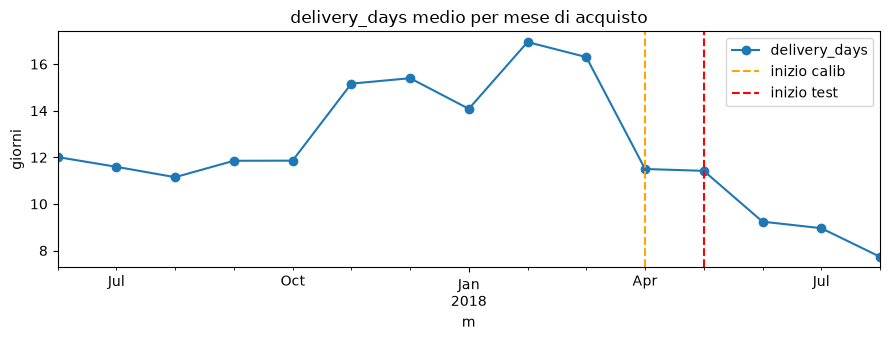

In [18]:
monthly = (ft.assign(m=pd.to_datetime(ft['purchase_date']).dt.to_period('M'))
             .groupby('m')['delivery_days'].mean())

print(f"fit:   {fit_df['purchase_date'].min()} -> {fit_df['purchase_date'].max()}  (media {y_fit.mean():.1f} gg)")
print(f"calib: {calib_df['purchase_date'].min()} -> {calib_df['purchase_date'].max()}  (media {y_calib.mean():.1f} gg)")
print(f"test:  {test['purchase_date'].min()} -> {test['purchase_date'].max()}  (media {y_test.mean():.1f} gg)")

monthly.tail(15).plot(marker='o', figsize=(9, 3.5))
plt.axvline(pd.Period(calib_df['purchase_date'].min(), 'M'), color='orange', linestyle='--', label='inizio calib')
plt.axvline(pd.Period(test['purchase_date'].min(), 'M'), color='red', linestyle='--', label='inizio test')
plt.title('delivery_days medio per mese di acquisto')
plt.ylabel('giorni')
plt.legend()
plt.tight_layout()
plt.show()

**Diagnosi confermata:** `delivery_days` scende in modo quasi monotono da fine 2017 (~16-17 gg, picco di rallentamento) fino ad agosto 2018 (~7-8 gg): le consegne migliorano nel tempo. Il periodo di calib (aprile-maggio 2018) e' ancora "lento" rispetto al test (giugno-agosto 2018): un margine tarato li' e' quindi troppo prudente per il test, e infatti sballa (quota di anticipi molto sotto il 5% target, a costo di un MAE peggiore della baseline).

**Conclusione pratica:** un margine (o una soglia) fissi, calibrati una volta su uno storico, non reggono bene se il fenomeno non e' stazionario nel tempo — servirebbe ricalibrare periodicamente su dati recenti in produzione. Una via piu' robusta *in fase di training* e' invece cercare il **peso della loss asimmetrica** (Sezione 7) via grid search, cosa che il gradient boosting puo' fare guardando l'intera storia invece di un singolo taglio temporale.

In [19]:
def make_asymmetric_mse(penalty):
    def obj(y_true, y_pred):
        residual = y_pred - y_true
        weight = np.where(residual < 0, penalty, 1.0)
        return 2 * weight * residual, 2 * weight
    return obj

rows = []
for penalty in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 10.0]:
    m = XGBRegressor(objective=make_asymmetric_mse(penalty), **xgb_params)
    m.fit(X_fit, y_fit)
    err_calib = m.predict(X_calib) - y_calib.to_numpy()
    err_test = m.predict(X_test) - y_test.to_numpy()
    rows.append((penalty,
                 np.abs(err_calib).mean(), (err_calib < 0).mean(),
                 np.abs(err_test).mean(), (err_test < 0).mean()))

grid = pd.DataFrame(rows, columns=['penalty', 'MAE_calib', 'early_calib', 'MAE_test', 'early_test'])
grid['early_calib'] = (grid['early_calib'] * 100).round(1)
grid['early_test'] = (grid['early_test'] * 100).round(1)
grid.round(2)

,penalty,MAE_calib,early_calib,MAE_test,early_test
0,1.0,5.49,26.2,6.04,12.5
1,1.5,6.07,22.0,6.94,10.0
2,2.0,6.60,19.1,7.68,8.4
3,2.5,7.06,17.0,8.28,7.3
4,3.0,7.47,15.4,8.82,6.5
5,4.0,8.19,13.2,9.70,5.4
6,5.0,8.84,11.1,10.43,4.7
7,7.0,9.88,9.2,11.63,3.8
8,10.0,11.11,7.1,12.94,3.1


## Sintesi Sezione 8

| approccio | MAE test (gg) | quota anticipi test |
|---|---|---|
| Random Forest (raw) | 5.99 | 12.7% |
| Random Forest (margine calibrato +9.0gg) | 14.10 | 1.8% |
| Logistic regression (95° percentile per costruzione) | 27.46 | 2.2% |
| XGBoost asimmetrico, penalty=3 (Sezione 7) | 8.82 | 6.5% |
| **XGBoost asimmetrico, penalty=4** | **9.70** | **5.4%** |
| **XGBoost asimmetrico, penalty=5** | **10.43** | **4.7%** |

- **Random Forest + margine fisso fallisce**: il margine (+9 gg) e' stimato sui residui di aprile-maggio 2018, un periodo ancora "lento". Applicato al test (giugno-agosto 2018, molto piu' veloce) e' troppo prudente: la quota di anticipi crolla all'1.8% ma il MAE (14.1 gg) diventa **peggiore della baseline stessa** (13.13 gg, Sezione 4). Root cause: `delivery_days` non e' stazionario nel tempo (grafico sopra) e un margine calibrato su uno storico "lento" non generalizza a un futuro piu' "veloce".
- **Logistic regression e' la peggiore in assoluto**: centra il target sull'anticipo (2.2%, sotto il 5%) ma con un MAE (27.5 gg) inaccettabile. Il confine lineare per bucket giornaliero non cattura le non-linearita' (soglie su distanza, categoria, tempo di approvazione) che i modelli ad alberi sfruttano: per restare "prudente per costruzione" deve spingere le previsioni molto in alto.
- **XGBoost asimmetrico con grid search vince nettamente**: il compromesso migliore trovato e' **penalty=4** (MAE 9.70 gg, anticipi 5.4%, appena sopra il target) o **penalty=5** se si vuole stare sicuri sotto il 5% (MAE 10.43 gg, anticipi 4.7%). Entrambi restano molto piu' precisi della baseline (13.13 gg) e della Random Forest calibrata (14.10 gg).

**Per il modello:** niente margine fisso post-hoc — il fenomeno non e' stazionario. Meglio (a) tenere il peso della loss asimmetrica come iperparametro di business scelto via grid search (qui `penalty=4-5`), e (b) **ricalibrare periodicamente** in produzione su una finestra recente, invece di fidarsi di una calibrazione fatta una volta su dati storici.

## 9. Tuning degli iperparametri (XGBoost asimmetrico)
Il modello vincente in Sezione 8 e' l'XGBoost con loss asimmetrica. Ha due famiglie di iperparametri, da tenere separate:
- **Architettura** (`max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`): quanto bene il modello impara i pattern. Non dipendono dalla preferenza di rischio, quindi si tunano con CV standard e **loss simmetrica**.
- **`penalty`**: e' una scelta di business (quanto costa anticipare vs ritardare), non un parametro statistico. Va scelto *dopo*, guardando MAE e quota di anticipi sul set di calibrazione (come in Sezione 8).

Mescolare le due cose in un'unica ricerca fa scegliere architetture "storte" solo per compensare il penalty. Meglio: prima l'architettura (qualita' predittiva), poi il penalty sopra quella.

**Architettura:** `RandomizedSearchCV` con `TimeSeriesSplit` (4 fold, niente shuffle: rispetta l'ordine temporale) sull'intero `train`, loss simmetrica.

In [20]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': np.logspace(np.log10(0.01), np.log10(0.2), 20),
    'n_estimators': [150, 200, 300, 400, 500],
    'subsample': np.linspace(0.6, 1.0, 9),
    'colsample_bytree': np.linspace(0.6, 1.0, 9),
    'min_child_weight': [1, 2, 3, 5, 7, 10],
}
base = XGBRegressor(objective='reg:squarederror', enable_categorical=True,
                     tree_method='hist', random_state=42)

search = RandomizedSearchCV(base, param_dist, n_iter=40, cv=TimeSeriesSplit(n_splits=4),
                             scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)  # X_train/y_train = tutto 'train' (Sezione 7)

best_arch = search.best_params_
print('Architettura scelta:', best_arch)
print(f'MAE CV (loss simmetrica): {-search.best_score_:.2f} gg')

Architettura scelta: {'subsample': np.float64(0.7), 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': np.float64(0.013707256063767185), 'colsample_bytree': np.float64(0.6)}
MAE CV (loss simmetrica): 5.59 gg


**Penalty:** stessa grid search della Sezione 8, ma sull'architettura appena trovata invece che su quella di default (`max_depth=5, learning_rate=0.05, n_estimators=300`, resto ai default).

In [21]:
rows = []
for penalty in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]:
    m = XGBRegressor(objective=make_asymmetric_mse(penalty), enable_categorical=True,
                      tree_method='hist', random_state=42, **best_arch)
    m.fit(X_fit, y_fit)
    err_calib = m.predict(X_calib) - y_calib.to_numpy()
    err_test = m.predict(X_test) - y_test.to_numpy()
    rows.append((penalty,
                 np.abs(err_calib).mean(), (err_calib < 0).mean(),
                 np.abs(err_test).mean(), (err_test < 0).mean()))

tuned_grid = pd.DataFrame(rows, columns=['penalty', 'MAE_calib', 'early_calib', 'MAE_test', 'early_test'])
tuned_grid['early_calib'] = (tuned_grid['early_calib'] * 100).round(1)
tuned_grid['early_test'] = (tuned_grid['early_test'] * 100).round(1)
tuned_grid.round(2)

,penalty,MAE_calib,early_calib,MAE_test,early_test
0,1.0,5.26,27.0,5.74,12.9
1,1.5,5.80,22.7,6.61,9.9
2,2.0,6.28,19.4,7.32,8.1
3,2.5,6.70,17.1,7.91,7.0
4,3.0,7.10,15.2,8.42,6.2
5,4.0,7.79,12.7,9.28,5.1
6,5.0,8.37,11.1,10.00,4.4
7,6.0,8.89,9.8,10.61,3.9
8,7.0,9.35,9.0,11.13,3.5
9,8.0,9.76,8.2,11.61,3.2


## Sintesi Sezione 9

**Architettura scelta:** `max_depth=5, learning_rate=0.014, n_estimators=300, subsample=0.7, colsample_bytree=0.6, min_child_weight=3` (MAE CV simmetrico 5.59 gg). Rispetto ai default della Sezione 8, e' piu' regolarizzata (`learning_rate` piu' basso, `subsample`/`colsample_bytree` < 1 per ridurre overfitting).

| architettura | penalty | MAE test | quota anticipi test |
|---|---|---|---|
| default (Sez. 8) | 4 | 9.70 | 5.4% |
| **tunata** | **4** | **9.28** | **5.1%** |
| default (Sez. 8) | 5 | 10.44 | 4.7% |
| **tunata** | **5** | **10.00** | **4.4%** |

L'architettura tunata **domina** quella di default a parita' di `penalty`: MAE piu' basso *e* quota di anticipi piu' bassa contemporaneamente (niente compromesso da fare tra le due). La CV con `TimeSeriesSplit` premia un modello piu' regolarizzato (meno overfit sulle fluttuazioni mensili viste in Sezione 8), che generalizza meglio sia in media che sulla coda sinistra degli errori.

**Scelta finale:**
- **`penalty=5`** se l'obiettivo e' stare sotto il 5% di anticipi con margine: MAE 10.00 gg, anticipi 4.4%.
- **`penalty=4`** se si accetta di sfiorare il 5% (5.1%) per guadagnare ~0.7 gg di MAE.

Entrambe restano nettamente migliori della baseline attuale (13.13 gg, Sezione 4) e della Random Forest calibrata (14.10 gg, Sezione 8).

**Per il modello:** tuning separato in due fasi (architettura via CV standard, poi `penalty` di business sul set di calibrazione) e' riutilizzabile: se si aggiungono feature o si aggiorna la finestra temporale, rifare la Sezione 9 senza dover rifare la diagnosi di Sezione 8.